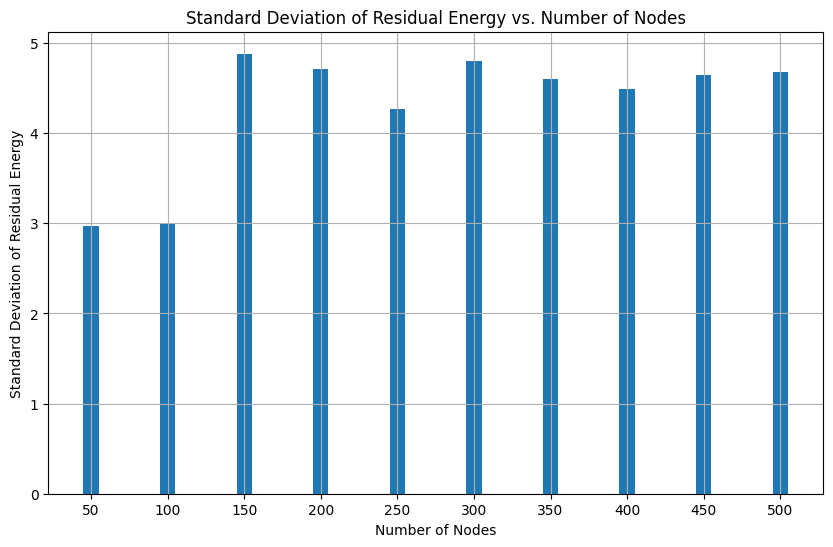

In [1]:
# Plot for Standard deviation of residual energy

import random
import math
import numpy as np
import matplotlib.pyplot as plt

# Constants
Eelec = 50e-9             # Electronics energy consumption per bit
Efs = 0.1e-9              # Amplifier energy consumption in free space
Emp = 0.000013e-9         # Amplifier energy consumption in multipath
do = 87                   # Threshold distance
packet_size = 800         # packet size
communication_range = 150 # Communication range (m)
Ts = 5                    # Maximum number of iterations for an individual whale
A = 0.5                   # Parameter for individual movement rule

# Function to calculate energy consumption for transmitting k bits of data
def energy_consumption(k, d):
    if d < do:
        return Eelec * k + Efs * k * d**2

    else:
        return Eelec * k + Emp * k * d**4

# Function to calculate energy consumption for receiving k bits of data
def receive_energy_consumption(k):

    return Eelec * k

# Function to calculate fitness of a path
def fitness_function(path, nodes):
    total_energy_consumption = 0
    average_residual_energy = 0
    min_residual_energy = float('inf')

    path_length = len(path)

    for i in range(1, path_length):
        current_node = path[i]
        previous_node = path[i - 1]

        distance = math.sqrt((nodes[current_node][0] - nodes[previous_node][0]) ** 2 + (nodes[current_node][1] - nodes[previous_node][1]) ** 2)

        total_energy_consumption += energy_consumption(packet_size, distance)
        total_energy_consumption += receive_energy_consumption(packet_size)

        average_residual_energy += nodes[current_node][2]
        min_residual_energy = min(min_residual_energy, nodes[current_node][2])

    average_residual_energy /= (path_length - 1)
    fitness = (total_energy_consumption * path_length * 1) / (average_residual_energy * min_residual_energy * 1)

    return fitness

# Function to calculate the Levenshtein distance between two paths (whales)
def levenshtein_distance(path1, path2):
    n = len(path1)
    m = len(path2)
    dp = np.zeros((n + 1, m + 1), dtype=int)

    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if path1[i - 1] == path2[j - 1]:
                cost = 0
            else:
                cost = 1
            dp[i, j] = min(dp[i - 1, j] + 1, dp[i, j - 1] + 1, dp[i - 1, j - 1] + cost)
    return dp[n, m]

# Function to initialize whale individuals randomly
def initialize_whales(num_whales, source_node, nodes):
    whales = []

    for i in range(num_whales):
        path = [source_node]
        current_node = source_node
        while current_node != sink_node:
            neighbors = [node for node in range(num_nodes) if math.sqrt((nodes[node][0] - nodes[current_node][0]) ** 2 + (nodes[node][1] - nodes[current_node][1]) ** 2) <= communication_range and node not in path]
            if neighbors:
                next_node = random.choice(neighbors)
                path.append(next_node)
                current_node = next_node
            else:
                break
        whales.append(path)

    return whales

# Function to perform local search for a whale individual
def local_search(whale, nodes):
    path_length = len(whale)
    for i in range(1, path_length - 1):
        current_node = whale[i]
        neighbors = [node for node in range(num_nodes) if math.sqrt((nodes[node][0] - nodes[current_node][0]) ** 2 + (nodes[node][1] - nodes[current_node][1]) ** 2) <= communication_range and node not in whale]
        if neighbors:
            new_node = random.choice(neighbors)
            new_whale = whale.copy()
            new_whale[i] = new_node
            new_fitness = fitness_function(new_whale, nodes)
            current_fitness = fitness_function(whale, nodes)
            if new_fitness < current_fitness:
                whale = new_whale
    return whale

# Function to find the "better and nearest" whale individual for a given whale
def find_better_nearest_whale(whale, whales, nodes):
    min_distance = float('inf')
    better_whale = None
    for other_whale in whales:
        if fitness_function(other_whale, nodes) < fitness_function(whale, nodes) and other_whale != whale:
            distance = levenshtein_distance(whale, other_whale)
            if distance < min_distance:
                min_distance = distance
                better_whale = other_whale
    return better_whale

def update_position(whale, better_whale, nodes):
    new_whale = [whale[0]]
    current_node = whale[0]
    i = 1
    k = 1
    while current_node != sink_node:
        # Check if k is within the bounds of both lists before accessing elements
        if k < len(whale) and k < len(better_whale):
            if better_whale[k] not in new_whale and math.sqrt((nodes[better_whale[k]][0] - nodes[current_node][0]) ** 2 + (nodes[better_whale[k]][1] - nodes[current_node][1]) ** 2) <= communication_range:
                # Calculate energy consumption for this transition
                energy_cost = energy_consumption(packet_size, math.sqrt((nodes[better_whale[k]][0] - nodes[current_node][0]) ** 2 + (nodes[better_whale[k]][1] - nodes[current_node][1]) ** 2))

                # Select the next node based on the minimum energy consumption
                neighbors = [node for node in range(num_nodes) if math.sqrt((nodes[node][0] - nodes[current_node][0]) ** 2 + (nodes[node][1] - nodes[current_node][1]) ** 2) <= communication_range and node not in new_whale]
                if neighbors:
                    # Find the neighbor with the lowest energy cost
                    min_energy_neighbor = min(neighbors, key=lambda neighbor: energy_consumption(packet_size, math.sqrt((nodes[neighbor][0] - nodes[current_node][0]) ** 2 + (nodes[neighbor][1] - nodes[current_node][1]) ** 2)))

                    # Check if the energy cost of the "better and nearest" whale is lower
                    if energy_cost <= energy_consumption(packet_size, math.sqrt((nodes[min_energy_neighbor][0] - nodes[current_node][0]) ** 2 + (nodes[min_energy_neighbor][1] - nodes[current_node][1]) ** 2)) or random.random() < A:
                        new_whale.append(better_whale[k])
                        current_node = better_whale[k]
                    else:
                        new_whale.append(min_energy_neighbor)
                        current_node = min_energy_neighbor
                else:
                    break
                k += 1
            else:
                # Choose the next node based on the minimum energy cost
                neighbors = [node for node in range(num_nodes) if math.sqrt((nodes[node][0] - nodes[current_node][0]) ** 2 + (nodes[node][1] - nodes[current_node][1]) ** 2) <= communication_range and node not in new_whale]
                if neighbors:
                    min_energy_neighbor = min(neighbors, key=lambda neighbor: energy_consumption(packet_size, math.sqrt((nodes[neighbor][0] - nodes[current_node][0]) ** 2 + (nodes[neighbor][1] - nodes[current_node][1]) ** 2)))
                    new_whale.append(min_energy_neighbor)
                    current_node = min_energy_neighbor
                else:
                    break
                i += 1
                k += 1  # Continue incrementing k even if one list is exhausted
        else:
            # Choose the next node based on the minimum energy cost
            neighbors = [node for node in range(num_nodes) if math.sqrt((nodes[node][0] - nodes[current_node][0]) ** 2 + (nodes[node][1] - nodes[current_node][1]) ** 2) <= communication_range and node not in new_whale]
            if neighbors:
                min_energy_neighbor = min(neighbors, key=lambda neighbor: energy_consumption(packet_size, math.sqrt((nodes[neighbor][0] - nodes[current_node][0]) ** 2 + (nodes[neighbor][1] - nodes[current_node][1]) ** 2)))
                new_whale.append(min_energy_neighbor)
                current_node = min_energy_neighbor
            else:
                break
            i += 1
            k += 1 # Continue incrementing k even if one list is exhausted
    return new_whale

# WSA-ICR algorithm
def wsa_icr(num_whales, num_nodes, nodes, source_node, sink_node):
    whales = initialize_whales(num_whales, source_node, nodes)
    # Initialize a list to store counters for each whale
    whale_counters = [0] * num_whales
    best_fitness = float('inf')
    best_path = None
    for i in range(num_iterations):
        for j in range(num_whales):
            whale = whales[j]
            better_whale = find_better_nearest_whale(whale, whales, nodes)
            if better_whale:
                if whale_counters[j] != Ts:
                    whale_counters[j] += 1
                else:
                    new_whale = update_position(whale, better_whale, nodes)
                    new_fitness = fitness_function(new_whale, nodes)
                    if new_fitness < best_fitness:
                        best_fitness = new_fitness
                        best_path = new_whale
                    whale = local_search(whale, nodes)
                    fitness = fitness_function(whale, nodes)
                    if fitness < best_fitness:
                        best_fitness = fitness
                        best_path = whale
                    whale_counters[j] = 0
            else:
                if whale_counters[j] != Ts:
                    whale_counters[j] += 1
                else:
                    fitness = fitness_function(whale, nodes)
                    if fitness < best_fitness:
                        best_fitness = fitness
                        best_path = whale
                    whale = local_search(whale, nodes)
                    fitness = fitness_function(whale, nodes)
                    if fitness < best_fitness:
                        best_fitness = fitness
                        best_path = whale
                    whale_counters[j] = 0

    for i in range(1, len(best_path)):
            current_node = best_path[i]
            previous_node = best_path[i - 1]

            distance = math.sqrt((nodes[current_node][0] - nodes[previous_node][0]) ** 2 + (nodes[current_node][1] - nodes[previous_node][1]) ** 2)

            energy_used = energy_consumption(packet_size, distance) + receive_energy_consumption(packet_size)
            nodes[current_node][2] -= energy_used

            if nodes[current_node][2] < 0:
                nodes[current_node][2] = 0

    return best_path, best_fitness

# Set number of iterations for the algorithm
num_iterations = 50


# Function to calculate standard deviation of residual energy in a path
def standard_deviation_residual_energy(path, nodes):
    residual_energies = [nodes[node_index][2] for node_index in path]
    return np.std(residual_energies)


# Experiment with varying number of nodes
num_nodes_list = [50,100,150,200,250,300,350,400,450,500]

standard_deviation_residual_energies = []

j=1
for num_nodes in num_nodes_list:

    # Generate random sensor nodes
    nodes = []

    for i in range(num_nodes):
        x = random.uniform(0, 200+100*j)
        y = random.uniform(0, 200+100*j)
        initial_energy = random.choice([6,12,18])  #Randomly select from 6,12,18 Joules
        nodes.append([x, y, initial_energy])

    # Select source and sink nodes
    source_node = 0
    sink_node = num_nodes - 1  # Set sink node to the last node

    # Run the WSA-ICR algorithm with periodic transmission
    best_path, best_fitness= wsa_icr(num_whales=10, num_nodes=num_nodes, nodes=nodes, source_node=source_node, sink_node=sink_node)

    # Calculate standard deviation of residual energy for the best path
    std_dev_residual_energy = standard_deviation_residual_energy(best_path, nodes)
    standard_deviation_residual_energies.append(std_dev_residual_energy)

    j+=1

# Plot standard deviation of residual energy
plt.figure(figsize=(10, 6))
plt.bar(num_nodes_list, standard_deviation_residual_energies, width=10)
plt.xlabel('Number of Nodes')
plt.ylabel('Standard Deviation of Residual Energy')
plt.title('Standard Deviation of Residual Energy vs. Number of Nodes')
plt.xticks(num_nodes_list)
plt.yticks(np.arange(0,6,1))
plt.grid(True)
plt.show()